In [14]:
import pandas as pd
import os

REPO_PATH = "/home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/"

# SincFold

SF_REL = REPO_PATH + "sincFold/SILVER/train_and_spy/last_epoch/sincFold_relf1.csv"
SF_OV_REL = REPO_PATH + "sincFold/SILVER/sincFold_ovs_w_val_20_relf1.csv"

# rna-llm

RNA_LLM_REL = REPO_PATH + "rna-llm-folding/SILVER/rel_f1_tables/"
RNA_LLM_OV_REL = REPO_PATH + "rna-llm-folding/SILVER/rel_f1_tables_ov/"

REDFOLD_REL = REPO_PATH + "REDFold/SILVER/200_epochs_relf1.csv"
UFOLD_REL = REPO_PATH + "UFold/SILVER/100_epochs_test_rel_f1_exact.csv"
# UFOLD_REL_lr = REPO_PATH + "UFold/SILVER/0_long_run100/100_epochs_test_rel_f1_exact.csv"
oh = "OneHot_15_epochs_relf1.csv"
rinalmo = "RiNALMo_15_epochs_relf1.csv"

In [15]:
sincfold = pd.read_csv(SF_REL, index_col=0)
sincfold_ov = pd.read_csv(SF_OV_REL, index_col=0)

rna_oh = pd.read_csv(RNA_LLM_REL + oh, index_col=0)
rna_oh_ov = pd.read_csv(RNA_LLM_OV_REL + oh, index_col=0)

rna_rinalmo = pd.read_csv(RNA_LLM_REL + rinalmo, index_col=0)
rna_rinalmo_ov = pd.read_csv(RNA_LLM_OV_REL + rinalmo, index_col=0)

redfold = pd.read_csv(REDFOLD_REL, index_col=0)
ufold = pd.read_csv(UFOLD_REL, index_col=0)
# ufold_lr = pd.read_csv(UFOLD_REL_lr, index_col=0)

In [16]:
print(sincfold)

        modelo    rel_f1
0  samples_200  1.053404
1       hc_400  1.083022
2  rnadist_400  1.107971
3  samples_400  1.123927
4       hc_200  1.141762
5  rnadist_200  1.169515
6  samples_100  1.195751
7       hc_100  1.209602
8  rnadist_100  1.224632


In [17]:
# Lista con los dataframes y sus nombres
dfs = {
    "sincFold": sincfold,
    "sincFold_ov": sincfold_ov,
    "ResNet_oh": rna_oh,
    "ResNet_ov": rna_oh_ov,
    "ResNet_rinalmo": rna_rinalmo,
    "ResNet_rinalmo_ov": rna_rinalmo_ov,
    "REDFold": redfold,
    "UFold": ufold,
    # "UFold_lr": ufold_lr,
}

# Transformar cada df: usar 'modelo' como índice y renombrar 'rel_f1'
for name, df in dfs.items():
    dfs[name] = df.set_index("modelo").rename(columns={"rel_f1": name})

# Unirlos por el índice 'modelo'
df_final = pd.concat(dfs.values(), axis=1)

# Cambiar nombre del índice
df_final.index.name = "Method"
df_final.sort_values(by="Method", inplace=True)
df_final

,sincFold,sincFold_ov,ResNet_oh,ResNet_ov,ResNet_rinalmo,ResNet_rinalmo_ov,REDFold,UFold
Method,,,,,,,,
hc_100,1.209602,1.114146,1.085338,1.063531,1.002279,1.002877,0.940601,1.046737
hc_200,1.141762,1.150147,1.108329,1.062606,1.010604,1.010742,1.027422,1.095534
hc_400,1.083022,0.971075,1.087027,1.018862,1.029806,1.042996,1.009881,1.078213
rnadist_100,1.224632,1.081777,1.078726,1.071620,0.995386,0.956648,0.979145,0.999120
rnadist_200,1.169515,1.106708,1.094044,1.082319,1.039072,1.012334,0.912625,1.072783
rnadist_400,1.107971,1.002313,1.044027,1.001857,1.025306,1.046823,1.009766,1.024511
samples_100,1.195751,1.085875,1.096974,1.040443,0.948652,0.980571,0.957442,1.107824
samples_200,1.053404,1.048353,1.052839,1.037077,0.993077,0.955050,0.941039,0.969386
samples_400,1.123927,1.038485,1.044917,1.011326,1.029185,1.038344,1.025665,1.031286


In [18]:
save = False
if save:
    df_final.to_csv("SILVER/rel_f1s.csv")

In [19]:
# Lista con los dataframes y sus nombres
dfs = {
    "sincFold": sincfold,
    "ResNet\n One-Hot": rna_oh,
    "ResNet\n RiNALMo": rna_rinalmo,
    "REDFold": redfold,
    "UFold": ufold,
    # "UFold_LR": ufold_lr,
}

# Transformar cada df: usar 'modelo' como índice y renombrar 'rel_f1'
for name, df in dfs.items():
    dfs[name] = df.set_index("modelo").rename(columns={"rel_f1": name})

# Unirlos por el índice 'modelo'
df_final = pd.concat(dfs.values(), axis=1)

# Cambiar nombre del índice
df_final.index.name = "metodo"
df_final.sort_values(by="metodo", inplace=True)
df_final

,sincFold,ResNet\n One-Hot,ResNet\n RiNALMo,REDFold,UFold
metodo,,,,,
hc_100,1.209602,1.085338,1.002279,0.940601,1.046737
hc_200,1.141762,1.108329,1.010604,1.027422,1.095534
hc_400,1.083022,1.087027,1.029806,1.009881,1.078213
rnadist_100,1.224632,1.078726,0.995386,0.979145,0.999120
rnadist_200,1.169515,1.094044,1.039072,0.912625,1.072783
rnadist_400,1.107971,1.044027,1.025306,1.009766,1.024511
samples_100,1.195751,1.096974,0.948652,0.957442,1.107824
samples_200,1.053404,1.052839,0.993077,0.941039,0.969386
samples_400,1.123927,1.044917,1.029185,1.025665,1.031286


In [20]:
save = False
if save:
    df_final.to_csv("SILVER/rel_f1s.csv")

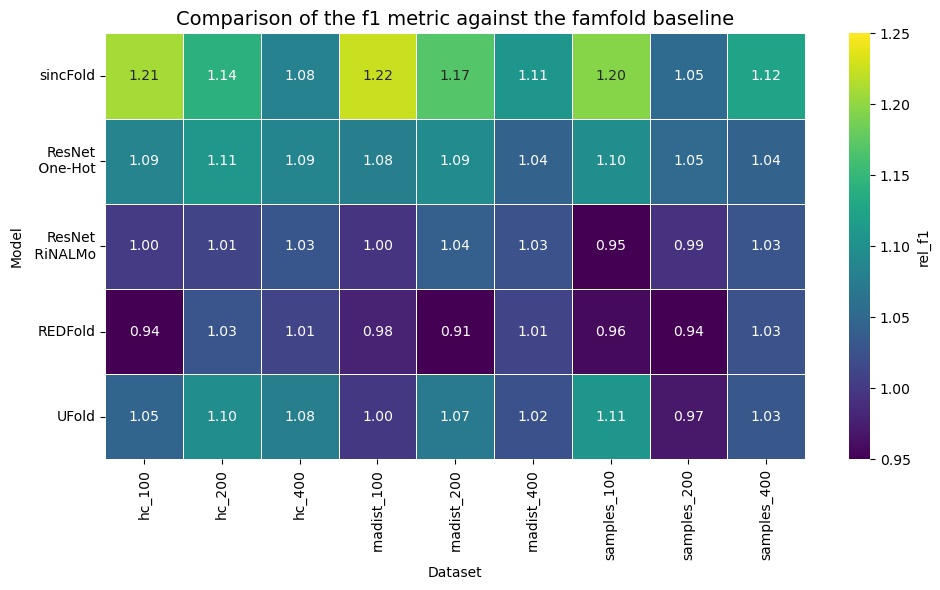

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(
    df_final.T,
    annot=True,  # Muestra los valores
    fmt=".2f",  # Formato de números
    cmap="viridis",  # Paleta de colores
    linewidths=0.5,  # Separadores de celdas
    cbar_kws={"label": "rel_f1"},  # Etiqueta de la barra de color
    vmin=0.95,
    vmax=1.25,
)
plt.title("Comparison of the f1 metric against the famfold baseline", fontsize=14)
plt.ylabel("Model")
plt.yticks(rotation=0)
plt.xlabel("Dataset")
plt.tight_layout()

FIGURE_PATH = "/home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/figures/"
#plt.savefig(FIGURE_PATH + "rel_f1s_heatmap.pdf", dpi=300)
plt.show()

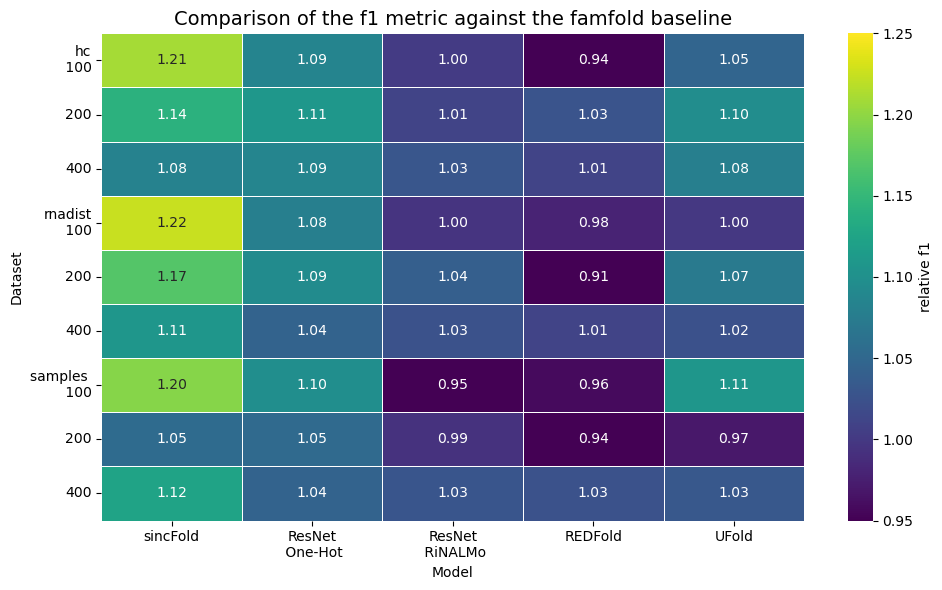

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
df_final.index = [
    'hc\n 100',
    '200',
    '400',    
    'rnadist\n 100',
    '200',
    '400',    
    'samples \n 100',
    '200',
    '400',
    ]
plt.figure(figsize=(10, 6))
sns.heatmap(
    df_final,
    annot=True,  # Muestra los valores
    fmt=".2f",  # Formato de números
    cmap="viridis",  # Paleta de colores
    linewidths=0.5,  # Separadores de celdas
    cbar_kws={"label": "relative f1"},  # Etiqueta de la barra de color
    vmin=0.95,
    vmax=1.25,
)
plt.title("Comparison of the f1 metric against the famfold baseline", fontsize=14)
plt.ylabel("Dataset")
plt.xlabel("Model")
plt.yticks(rotation=0)
plt.tight_layout()

FIGURE_PATH = "/home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/figures/"
#plt.savefig(FIGURE_PATH + "rel_f1s_heatmap_v3.pdf", dpi=300)
plt.show()

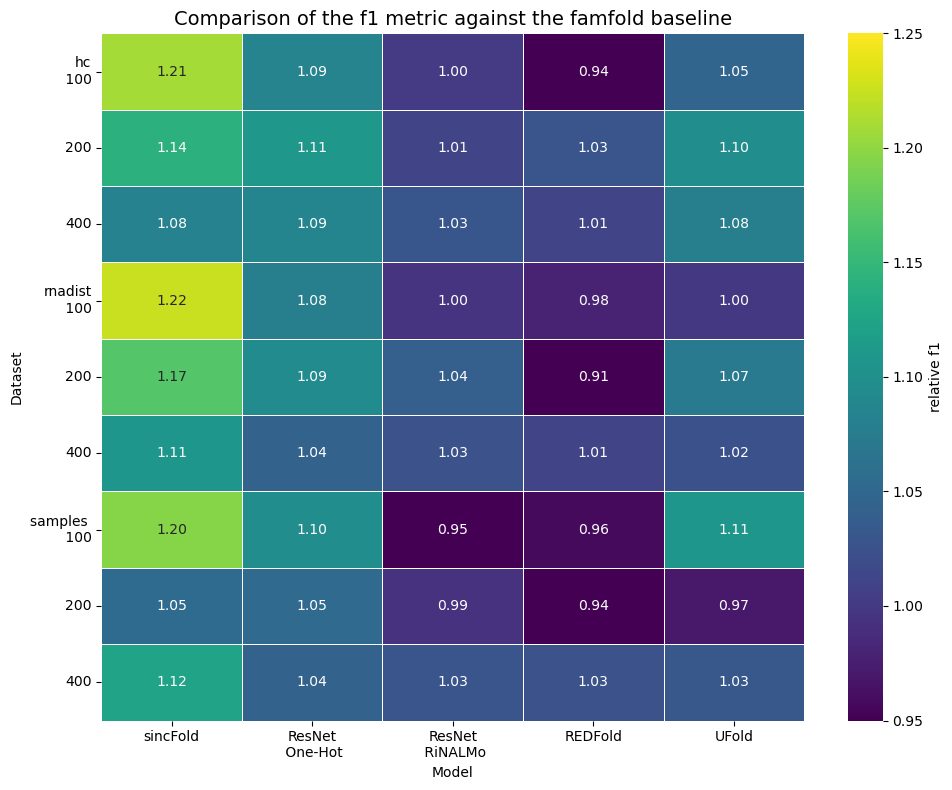

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
df_final.index = [
    'hc\n 100',
    '200',
    '400',    
    'rnadist\n 100',
    '200',
    '400',    
    'samples \n 100',
    '200',
    '400',
    ]
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_final,
    annot=True,  # Muestra los valores
    fmt=".2f",  # Formato de números
    cmap="viridis",  # Paleta de colores
    linewidths=0.5,  # Separadores de celdas
    cbar_kws={"label": "relative f1"},  # Etiqueta de la barra de color
    vmin=0.95,
    vmax=1.25,
)
plt.title("Comparison of the f1 metric against the famfold baseline", fontsize=14)
plt.ylabel("Dataset")
plt.xlabel("Model")
plt.yticks(rotation=0)
plt.tight_layout()

FIGURE_PATH = "/home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/figures/"
#plt.savefig(FIGURE_PATH + "rel_f1s_heatmap_v4.pdf", dpi=300)
plt.show()

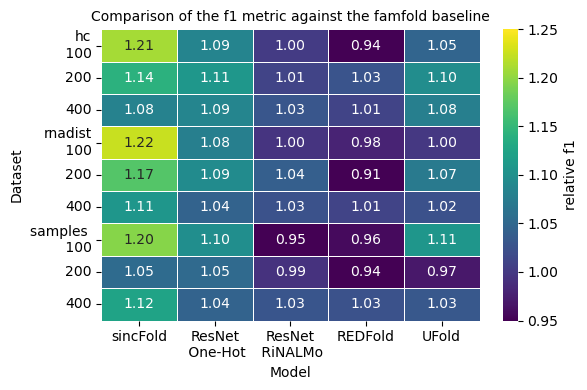

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
df_final.index = [
    'hc\n 100',
    '200',
    '400',    
    'rnadist\n 100',
    '200',
    '400',    
    'samples \n 100',
    '200',
    '400',
    ]
plt.figure(figsize=(6, 4))
sns.heatmap(
    df_final,
    annot=True,  # Muestra los valores
    fmt=".2f",  # Formato de números
    cmap="viridis",  # Paleta de colores
    linewidths=0.5,  # Separadores de celdas
    cbar_kws={"label": "relative f1"},  # Etiqueta de la barra de color
    vmin=0.95,
    vmax=1.25,
)
plt.title("Comparison of the f1 metric against the famfold baseline", fontsize=10)
plt.ylabel("Dataset")
plt.xlabel("Model")
plt.yticks(rotation=0)
plt.tight_layout() 
plt.show()

In [11]:
# Lista con los dataframes y sus nombres
dfs = {
    "sincFold": sincfold_ov,
    "RNALLM_oh": rna_oh_ov,
    "RNALLM_rinalmo": rna_rinalmo_ov,
}

# Transformar cada df: usar 'modelo' como índice y renombrar 'rel_f1'
for name, df in dfs.items():
    dfs[name] = df.set_index("modelo").rename(columns={"rel_f1": name})

# Unirlos por el índice 'modelo'
df_final = pd.concat(dfs.values(), axis=1)

# Cambiar nombre del índice
df_final.index.name = "metodo_ov"
df_final.sort_values(by="metodo_ov", inplace=True)
df_final

,sincFold,RNALLM_oh,RNALLM_rinalmo
metodo_ov,,,
hc_100,1.114146,1.063531,1.002877
hc_200,1.150147,1.062606,1.010742
hc_400,0.971075,1.018862,1.042996
rnadist_100,1.081777,1.071620,0.956648
rnadist_200,1.106708,1.082319,1.012334
rnadist_400,1.002313,1.001857,1.046823
samples_100,1.085875,1.040443,0.980571
samples_200,1.048353,1.037077,0.955050
samples_400,1.038485,1.011326,1.038344


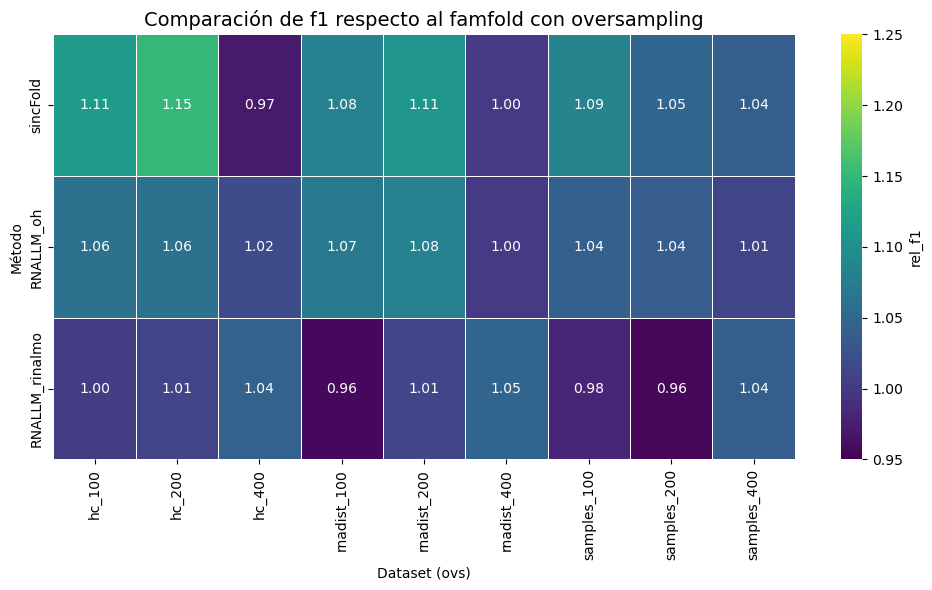

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(
    df_final.T,
    annot=True,  # Muestra los valores
    fmt=".2f",  # Formato de números
    cmap="viridis",  # Paleta de colores
    linewidths=0.5,  # Separadores de celdas
    cbar_kws={"label": "rel_f1"},  # Etiqueta de la barra de color
    vmin=0.95,
    vmax=1.25,
)
plt.title("Comparación de f1 respecto al famfold con oversampling", fontsize=14)
plt.ylabel("Método")
plt.xlabel("Dataset (ovs)")
plt.tight_layout()
plt.show()